In [0]:
# ==========================================
# Import Required Libraries
# ==========================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

In [0]:
from pyspark.sql.types import *

schema = StructType([
    StructField("main_category", StringType()),
    StructField("title", StringType()),
    StructField("average_rating", DoubleType()),
    StructField("rating_number", LongType()),
    StructField("features", ArrayType(StringType())),
    StructField("description", ArrayType(StringType())),
    StructField("price", DoubleType()),
    StructField("images", ArrayType(MapType(StringType(), StringType()))),
    StructField("videos", ArrayType(MapType(StringType(), StringType()))),
    StructField("store", StringType()),
    StructField("categories", ArrayType(StringType())),
    StructField("details", MapType(StringType(), StringType())),
    StructField("parent_asin", StringType()),
    StructField("bought_together", StringType())
])

meta_df = spark.read.schema(schema).json(
    "/Volumes/project/default/data/meta_Appliances.jsonl"
)

In [0]:
from pyspark.sql.types import *

review_schema = StructType([
    StructField("asin", StringType()),
    StructField("helpful_vote", LongType()),

    StructField(
        "images",
        ArrayType(
            StructType([
                StructField("attachment_type", StringType()),
                StructField("large_image_url", StringType()),
                StructField("medium_image_url", StringType()),
                StructField("small_image_url", StringType())
            ])
        )
    ),

    StructField("parent_asin", StringType()),
    StructField("rating", DoubleType()),
    StructField("text", StringType()),
    StructField("timestamp", LongType()),
    StructField("title", StringType()),
    StructField("user_id", StringType()),
    StructField("verified_purchase", BooleanType())
])

reviews_df = spark.read.schema(review_schema).json(
    "/Volumes/project/default/data/Appliances.jsonl"
)

In [0]:
print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)

print(f"Metadata Records : {meta_df.count():,}")
print(f"Review Records   : {reviews_df.count():,}")

DATASET LOADED SUCCESSFULLY
Metadata Records : 94,327
Review Records   : 2,128,605


In [0]:
# ==========================================
# Dataset Dimensions
# ==========================================

meta_rows = meta_df.count()
meta_cols = len(meta_df.columns)

review_rows = reviews_df.count()
review_cols = len(reviews_df.columns)

overview = pd.DataFrame({
    "Dataset": ["Metadata", "Reviews"],
    "Rows": [meta_rows, review_rows],
    "Columns": [meta_cols, review_cols]
})

overview

,Dataset,Rows,Columns
0,Metadata,94327,14
1,Reviews,2128605,10


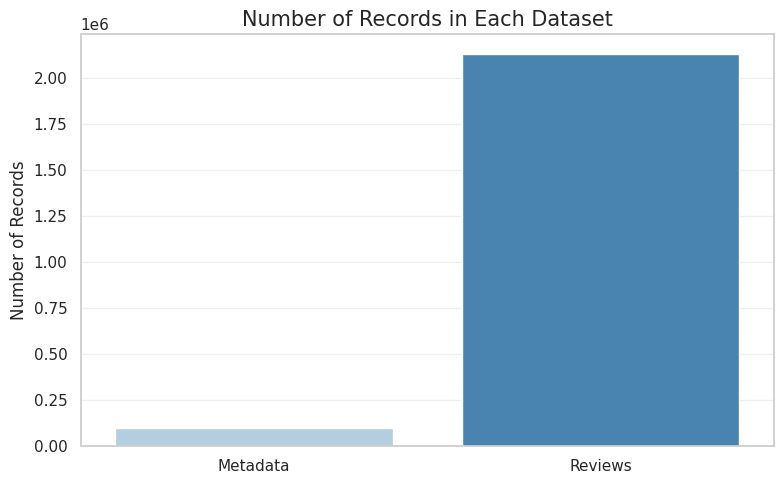

In [0]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=overview,
    x="Dataset",
    y="Rows",
    hue="Dataset",
    palette="Blues"
)

plt.title("Number of Records in Each Dataset")
plt.ylabel("Number of Records")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
print("=" * 80)
print("Metadata Schema")
print("=" * 80)

meta_df.printSchema()

print("\n")

print("=" * 80)
print("Review Schema")
print("=" * 80)

reviews_df.printSchema()

Metadata Schema
root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: map (containsNull = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)
 |-- videos: array (nullable = true)
 |    |-- element: map (containsNull = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- details: map (nullable = true)
 |    |-- key: string
 |    |-- value: string (valueContainsNull = true)
 |-- parent_asin: string (nul

In [0]:
print("Metadata Sample")
display(meta_df.limit(5))

print("Review Sample")
display(reviews_df.limit(5))

Metadata Sample


main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
Industrial & Scientific,"ROVSUN Ice Maker Machine Countertop, Make 44lbs Ice in 24 Hours, Compact & Portable Ice Maker with Ice Basket for Home, Office, Kitchen, Bar (Silver)",3.7,61,"List(【Quick Ice Making】This countertop ice machine creates crystal & bullet shaped ice cubes; 44lbs of ice ready in 24 hours, 12 cubes made per cycle within 10 mins; you can perfectly use it for drinks, wine, smoothies, food, 【Portable Design】The weight of this ice maker is only 23.3lbs, and the small size (10.63 x14.37 x 12.87)"" makes it portable. It's compact feature is perfect for home, office, apartments, dormitories, RVs and more, it can be placed on countertop or tabletop, plug it anywhere you like, 【Simple Operation】Adding the water tank with purified water; Power on machine and press ""on/off"" button to start ice making process; After 8-12 minutes, ice cube will fall off into the ice basket automatically; Take it out and make you cool, 【Full Monitoring】 Designed with compressor cooling system, operates at low noise and will not disturb your normal life; See-through window on top allows you to easily view the progress and check ice level, 【1 Year Warranty】We do cover 1 year warranty on this ice maker, any questions about it, please don't hesitate to contact us at any time for getting a satisfied service. Worry free purchase, so get this ice machine home today)",List(),null,"List(Map(thumb -> https://m.media-amazon.com/images/I/31idkuA3KlL._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/31idkuA3KlL.jpg, variant -> MAIN, hi_res -> https://m.media-amazon.com/images/I/61zNIJh6ZCL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41-MiODg9xL._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/41-MiODg9xL.jpg, variant -> PT01, hi_res -> https://m.media-amazon.com/images/I/71i3VazBG1L._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41wDXfH8m8L._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/41wDXfH8m8L.jpg, variant -> PT02, hi_res -> https://m.media-amazon.com/images/I/71INhlaKSGL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41U-3N4Al4L._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/41U-3N4Al4L.jpg, variant -> PT03, hi_res -> https://m.media-amazon.com/images/I/71IjZxwpPgL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/51ZMIaw5j+L._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/51ZMIaw5j+L.jpg, variant -> PT04, hi_res -> https://m.media-amazon.com/images/I/8154EOa6mML._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41rxwKw1FqL._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/41rxwKw1FqL.jpg, variant -> PT05, hi_res -> https://m.media-amazon.com/images/I/71P3bDmPIXL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/5146wcOEdfL._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/5146wcOEdfL.jpg, variant -> PT06, hi_res -> https://m.media-amazon.com/images/I/71ST326RerL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/61-9E6JF51L._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/61-9E6JF51L.jpg, variant -> PT07, hi_res -> https://m.media-amazon.com/images/I/81I6c2yZStL._SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/51+Ddh3KfhL._SX38_SY50_CR,0,0,38,50_.jpg, large -> https://m.media-amazon.com/images/I/51+Ddh3KfhL.jpg, variant -> PT08, hi_res -> https://m.media-amazon.com/images/I/71Dap4gcywL._SL1500_.jpg))","List(Map(title -> Our Point of View on the Euhomy Ice Maker Machine, url -> https://www.amazon.com/vdp/04e6baae04404579891e175567cb7b9d?ref=dp_vse_rvc_0, user_id -> /shop/influencer-20a38664), Map(title -> Frigidaire Ice Maker, Stainless (5 Stars) , url -> https://www.amazon.c

Review Sample


asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
B01N0TQ0OH,0,List(),B01N0TQ0OH,5.0,work great. use a new one every month,1519317108692,Work great,AGKHLEW2SOWHNMFQIJGBECAF7INQ,true
B07DD2DMXB,0,List(),B07DD37QPZ,5.0,Little on the thin side,1664746863446,excellent product,AHWWLSPCJMALVHDDVSUGICL6RUCA,true
B082W3Z9YK,0,List(),B082W3Z9YK,5.0,"Quick delivery, fixed the issue!",1607225435363,Happy customer!,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,true
B078W2BJY8,0,List(),B078W2BJY8,5.0,"I wasn't sure whether these were worth it or not, given the cost compared to the original branded filters.I can happily report that these are a great value and work every bit as good as the original. If you are on the fence worrying whether these are worth it- I can assure you they are.",1534104184306,Amazing value,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,true
B08C9LPCQV,0,List(),B08C9LPCQV,5.0,Easy to install got the product expected to receive,1620176603754,Dryer parts,AELFJFAXQERUSMTXJQ6SYFFRDWMA,true


In [0]:
# Metadata Columns
meta_columns = pd.DataFrame({
    "Column Name": meta_df.columns,
    "Data Type": [dtype for _, dtype in meta_df.dtypes]
})

meta_columns

,Column Name,Data Type
0,main_category,string
1,title,string
2,average_rating,double
3,rating_number,bigint
4,features,array<string>
5,description,array<string>
6,price,double
7,images,"array<map<string,string>>"
8,videos,"array<map<string,string>>"
9,store,string


In [0]:
# Review Columns
review_columns = pd.DataFrame({
    "Column Name": reviews_df.columns,
    "Data Type": [dtype for _, dtype in reviews_df.dtypes]
})

review_columns

,Column Name,Data Type
0,asin,string
1,helpful_vote,bigint
2,images,"array<struct<attachment_type:string,large_imag..."
3,parent_asin,string
4,rating,double
5,text,string
6,timestamp,bigint
7,title,string
8,user_id,string
9,verified_purchase,boolean


In [0]:
# ==========================================
# Missing Values - Metadata Dataset
# ==========================================

meta_total = meta_df.count()

meta_missing = []

for col in meta_df.columns:
    missing = meta_df.filter(F.col(col).isNull()).count()

    meta_missing.append({
        "Column": col,
        "Missing Values": missing,
        "Missing Percentage": round((missing/meta_total)*100,2)
    })

meta_missing_df = pd.DataFrame(meta_missing)

meta_missing_df.sort_values(
    by="Missing Percentage",
    ascending=False,
    inplace=True
)

meta_missing_df

,Column,Missing Values,Missing Percentage
13,bought_together,94327,100.00
6,price,47601,50.46
0,main_category,4676,4.96
9,store,916,0.97
1,title,0,0.00
2,average_rating,0,0.00
3,rating_number,0,0.00
4,features,0,0.00
5,description,0,0.00
7,images,0,0.00


In [0]:
# ==========================================
# Missing Values - Review Dataset
# ==========================================

review_total = reviews_df.count()

review_missing = []

for col in reviews_df.columns:
    missing = reviews_df.filter(F.col(col).isNull()).count()

    review_missing.append({
        "Column": col,
        "Missing Values": missing,
        "Missing Percentage": round((missing/review_total)*100,2)
    })

review_missing_df = pd.DataFrame(review_missing)

review_missing_df.sort_values(
    by="Missing Percentage",
    ascending=False,
    inplace=True
)

review_missing_df

,Column,Missing Values,Missing Percentage
0,asin,0,0.0
1,helpful_vote,0,0.0
2,images,0,0.0
3,parent_asin,0,0.0
4,rating,0,0.0
5,text,0,0.0
6,timestamp,0,0.0
7,title,0,0.0
8,user_id,0,0.0
9,verified_purchase,0,0.0


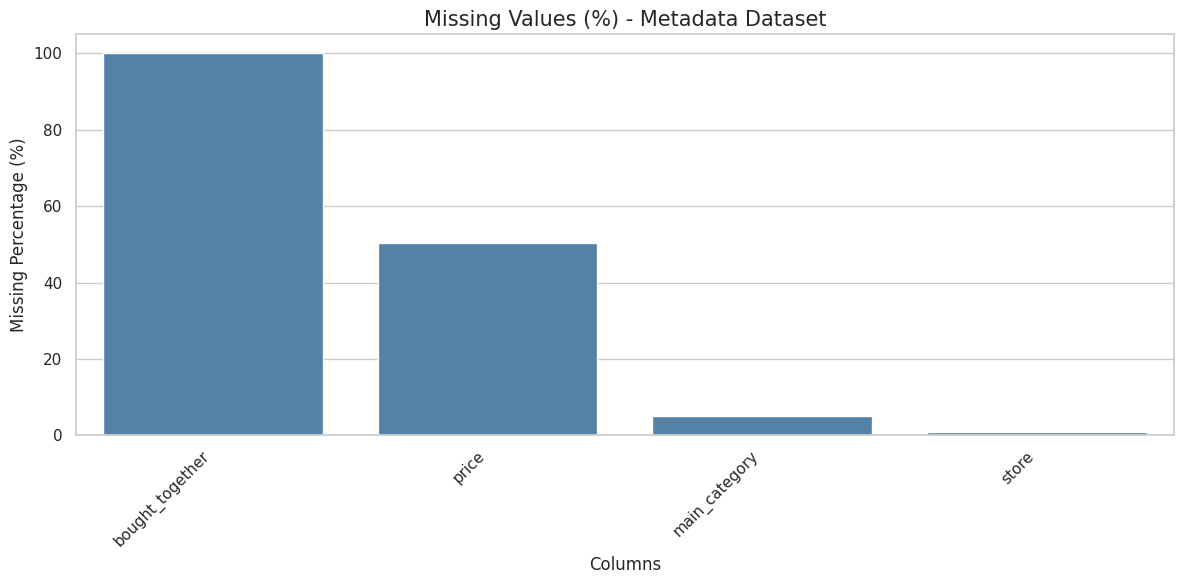

In [0]:
plt.figure(figsize=(12,6))

plot_df = meta_missing_df[meta_missing_df["Missing Values"] > 0]

sns.barplot(
    data=plot_df,
    x="Column",
    y="Missing Percentage",
    color="steelblue"
)

plt.xticks(rotation=45, ha="right")

plt.title("Missing Values (%) - Metadata Dataset")

plt.ylabel("Missing Percentage (%)")

plt.xlabel("Columns")

plt.tight_layout()

plt.show()

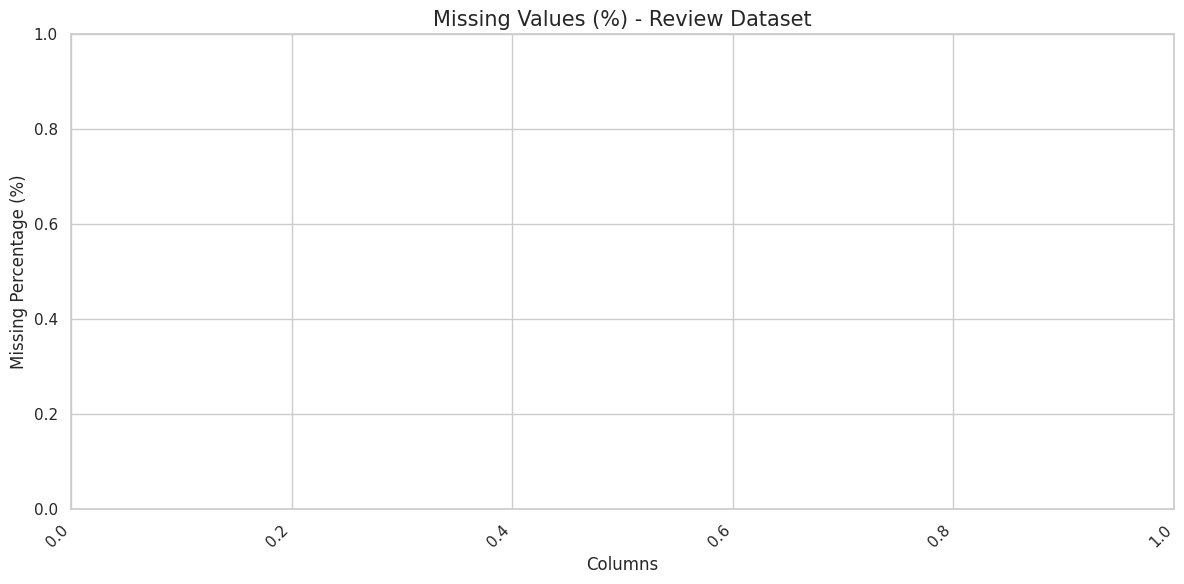

In [0]:
plt.figure(figsize=(12,6))

plot_df = review_missing_df[review_missing_df["Missing Values"] > 0]

sns.barplot(
    data=plot_df,
    x="Column",
    y="Missing Percentage",
    color="darkorange"
)

plt.xticks(rotation=45, ha="right")

plt.title("Missing Values (%) - Review Dataset")

plt.ylabel("Missing Percentage (%)")

plt.xlabel("Columns")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Metadata Duplicate Analysis
# ==========================================

meta_total = meta_df.count()

meta_unique = meta_df.select("parent_asin").distinct().count()

meta_duplicates = meta_total - meta_unique

summary_meta = pd.DataFrame({
    "Metric":[
        "Total Product Records",
        "Unique Product IDs",
        "Duplicate Product Records"
    ],
    "Value":[
        meta_total,
        meta_unique,
        meta_duplicates
    ]
})

summary_meta

,Metric,Value
0,Total Product Records,94327
1,Unique Product IDs,94327
2,Duplicate Product Records,0


In [0]:
# ==========================================
# Review Duplicate Analysis
# ==========================================

review_total = reviews_df.count()

review_unique = (
    reviews_df
    .select(
        "user_id",
        "parent_asin",
        "timestamp"
    )
    .distinct()
    .count()
)

review_duplicates = review_total - review_unique

summary_review = pd.DataFrame({
    "Metric":[
        "Total Review Records",
        "Unique Review Records",
        "Duplicate Review Records"
    ],
    "Value":[
        review_total,
        review_unique,
        review_duplicates
    ]
})

summary_review

,Metric,Value
0,Total Review Records,2128605
1,Unique Review Records,2105948
2,Duplicate Review Records,22657
